# Intracellular master-regulators of atopic dermatitis — reproducible highlights

**Runs in under a minute off saved checkpoints — no 16 GB download.**

This companion notebook reproduces the three headline results of the project from
precomputed checkpoints:

1. **The pivotal finding** — STAT6 and GATA3 knockouts do *not* phenocopy each other in
   circulating CD4⁺ T cells (GATA3 collapses the type-2 cytokines; STAT6 does not).
2. **Pipeline validation** — both anchors self-recover at rank 1 in the phenocopy screen.
3. **Independent ML confirmation** — a classifier trained with the label genes removed
   ranks GATA3 #4 / 6,923 but STAT6 #4,809.

For the *full* screen from the raw 16 GB atlas, see `pipeline/run_th2_screen.py`.

**Data citation:** Zhu R, Dann E, Yan J, *et al.* "Genome-scale perturb-seq in primary
human CD4+ T cells maps context-specific regulators of T cell programs and human immune
traits." *bioRxiv* (2025), doi:10.64898/2025.12.23.696273 (senior authors J.K. Pritchard
& A. Marson). Literature citations via PubMed.

## 0. Setup

Checkpoints expected in `data/`, ranked tables in `results/`. The z-score matrix
(33,983 perturbation×condition signatures × 10,282 genes, float32 ≈ 1.4 GB) and the
observation table are the only heavy inputs — both are precomputed, so nothing here
touches the 16 GB source object.

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data"); RES = Path("results")

npz = np.load(DATA / "de_zscore_matrix.npz", allow_pickle=True)
Z          = npz["zscore"]                       # (33983, 10282) float32
gene_name  = npz["gene_name"].astype(str)        # (10282,)
obs        = pd.read_parquet(DATA / "de_obs.parquet")
g2i        = {g: i for i, g in enumerate(gene_name)}
print("z-matrix:", Z.shape, Z.dtype, "| obs:", obs.shape)

z-matrix: (33983, 10282) float32 | obs: (33983, 28)


## 1. Eligibility filter

Keep only high-confidence perturbations: significant on-target knockdown, and free of
neighbouring-gene, distal-off-target, and low-target-expression flags.

In [5]:
elig = (obs.ontarget_significant
        & ~obs.neighboring_gene_KD
        & ~obs.distal_offtarget_flag
        & ~obs.low_target_gex)
print(f"eligible: {int(elig.sum())} / {len(obs)}")
print(obs.loc[elig, "culture_condition"].value_counts().to_dict())

eligible: 18622 / 33983
{'Stim48hr': 6371, 'Stim8hr': 6251, 'Rest': 6000}


## 2. The pivotal finding — STAT6 ≠ GATA3

We read the two anchor knockouts' effects on canonical type-2 and Th1 genes, in the
strongest stimulated condition (Stim48hr). **GATA3 knockout collapses the type-2
cytokines** (large negative z on IL13/IL5/IL4/CCR4). **STAT6 knockout does not** — several
type-2 genes go *up*, and Th1 IFNG is de-repressed. In committed circulating cells GATA3
maintains the allergic program independently of STAT6.

In [7]:
def anchor_row(anchor, cond="Stim48hr"):
    m = (obs.target_contrast_gene_name == anchor) & (obs.culture_condition == cond)
    return Z[np.where(m.values)[0][0]]

panel = ["IL13","IL5","IL4","CCR4","GATA3","MAF","IL2RA","IFNG","CISH","BATF"]
zg, zs = anchor_row("GATA3"), anchor_row("STAT6")
tbl = pd.DataFrame({"gene": panel,
                    "GATA3_KO_z": [zg[g2i[g]] if g in g2i else np.nan for g in panel],
                    "STAT6_KO_z": [zs[g2i[g]] if g in g2i else np.nan for g in panel]})
print(tbl.round(2).to_string(index=False))

 gene  GATA3_KO_z  STAT6_KO_z
 IL13       -7.65        4.25
  IL5       -4.70       -2.24
  IL4       -3.58        2.32
 CCR4       -9.52       -4.55
GATA3      -14.95       -2.22
  MAF       -3.54        0.28
IL2RA      -11.27        3.00
 IFNG       -2.99        4.92
 CISH        3.20       -6.72
 BATF       -4.39       -6.00


In [8]:
r = np.corrcoef(zg, zs)[0, 1]
print(f"STAT6 vs GATA3 whole-transcriptome z correlation (Stim48hr): r = {r:.3f}")
print("-> the two 'Th2 master regulators' do NOT phenocopy each other in circulating cells.")

STAT6 vs GATA3 whole-transcriptome z correlation (Stim48hr): r = -0.088
-> the two 'Th2 master regulators' do NOT phenocopy each other in circulating cells.


## 3. Pipeline validation — both anchors self-recover at rank 1

The genome-wide phenocopy screen (precomputed in `results/`) scores every eligible
perturbation against each anchor's knockout signature. Each anchor comes back as its own
#1 hit — the built-in positive control — and the top neighbours are the expected biology
(GATA3→TPD52/chromatin machinery; STAT6→IL4R, its upstream receptor).

In [10]:
for anchor in ["GATA3","STAT6"]:
    s = pd.read_csv(RES / f"screen_{anchor}_ranked.csv")
    scol = "cosine_mean" if "cosine_mean" in s.columns else [c for c in s.columns if "cos" in c][0]
    gcol = "gene" if "gene" in s.columns else s.columns[0]
    s = s.sort_values(scol, ascending=False).reset_index(drop=True)
    self_rank = s.index[s[gcol] == anchor][0] + 1
    print(f"[{anchor}] self rank {self_rank}  (cosine {s.loc[self_rank-1, scol]:.3f})")
    print("   top hits:", ", ".join(s[gcol].head(6).tolist()), "\n")

[GATA3] self rank 1  (cosine 0.870)
   top hits: GATA3, TPD52, SMARCA4, ZNF649, SEC14L2, KMT2C 

[STAT6] self rank 1  (cosine 0.860)
   top hits: STAT6, IL4R, FBXO32, PTPRC, NCAPG2, CLCC1 



## 4. Independent ML confirmation

A supervised classifier (ROC-AUC 0.94) trained on transcriptome-wide response — with the
8 type-2 effector *label* genes removed from the features to block leakage — independently
reproduces the divergence: **GATA3 ranks near the very top, STAT6 near the bottom.**

In [12]:
pred = pd.read_csv(RES / "classifier_predictions.csv")
pcol = [c for c in pred.columns if "prob" in c.lower()][0]
pred = pred.sort_values(pcol, ascending=False).reset_index(drop=True)
for g in ["GATA3","BATF","IL4R","STAT6"]:
    if (pred.gene == g).any():
        rk = pred.index[pred.gene == g][0] + 1
        print(f"{g:6s} rank {rk:5d} / {len(pred)}   collapse prob = {pred.loc[rk-1, pcol]:.3f}")

GATA3  rank     4 / 6923   collapse prob = 0.977
BATF   rank   166 / 6923   collapse prob = 0.686
IL4R   rank  1281 / 6923   collapse prob = 0.085
STAT6  rank  4809 / 6923   collapse prob = 0.004


## 5. One figure — the divergence at a glance

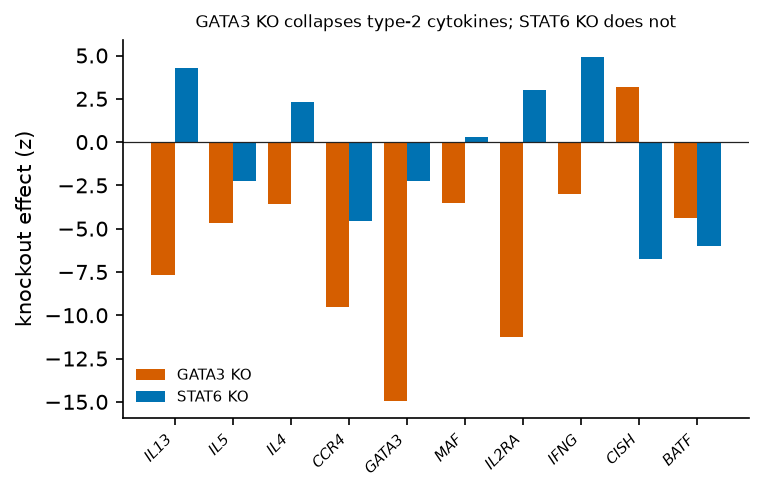

In [14]:
fig, ax = plt.subplots(figsize=(5.2, 3.4))
xs = np.arange(len(panel)); w = 0.4
ax.bar(xs - w/2, tbl.GATA3_KO_z, w, label="GATA3 KO", color="#D55E00")
ax.bar(xs + w/2, tbl.STAT6_KO_z, w, label="STAT6 KO", color="#0072B2")
ax.axhline(0, color="#222", lw=0.6)
ax.set_xticks(xs); ax.set_xticklabels([f"$\\it{{{g}}}$" for g in panel], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("knockout effect (z)"); ax.set_title("GATA3 KO collapses type-2 cytokines; STAT6 KO does not", fontsize=8)
ax.legend(frameon=False, fontsize=7)
for s in ["top","right"]: ax.spines[s].set_visible(False)
fig.tight_layout(); plt.show()

---
### Provenance (Claude Science artifact version IDs)

| File | Version ID |
|------|-----------|
| `data/de_zscore_matrix.npz` | `b3ee6800-4c2b-461b-aadb-37e300aa5f86` |
| `data/de_obs.parquet` | `aa80effd-8ec5-4dfa-960d-e066b6eb2eb4` |
| `results/screen_GATA3_ranked.csv` | `3510784a-47c8-4e8a-8b23-fbfc0a002006` |
| `results/screen_STAT6_ranked.csv` | `c5d018cf-442a-4197-8eed-cd84cbb9db41` |
| `results/classifier_predictions.csv` | `99fadd40-4b72-4e73-927f-bebbbaa6b90c` |

Full methods & results: `METHODS_and_RESULTS.md`. Full screen from raw data:
`pipeline/run_th2_screen.py`.